# Electricity Consumption Prediction

---
### Import necessary libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('electricity_data.csv')
print("Dataset Loaded Successfully!")
df.head()

Dataset Loaded Successfully!


,Date,Temperature_C,Humidity_Percent,Day_of_Week,Is_Holiday,Usage_kWh
0,2026-07-01,30.5,60,2,0,15.2
1,2026-07-02,31.2,58,3,0,16.5
2,2026-07-03,32.0,55,4,0,17.8
3,2026-07-04,33.5,52,5,0,19.2
4,2026-07-05,29.0,65,6,0,14.5


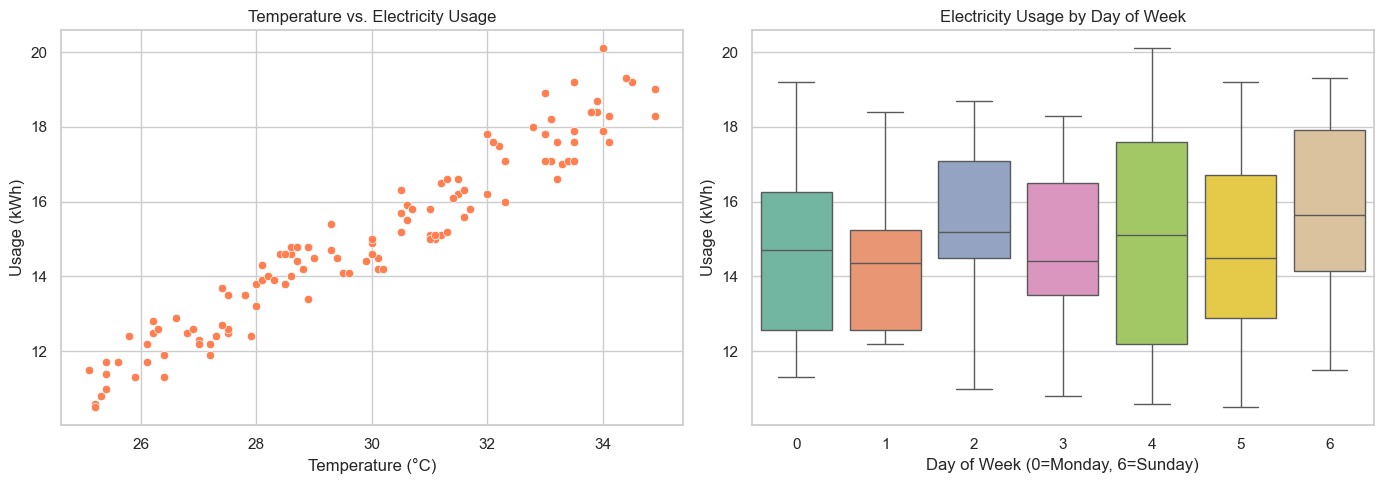

In [2]:
# Set up the plotting environment
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Temperature vs Electricity Usage
sns.scatterplot(data=df, x='Temperature_C', y='Usage_kWh', ax=axes[0], color='coral')
axes[0].set_title('Temperature vs. Electricity Usage')
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Usage (kWh)')

# Plot 2: Weekly Consumption Patterns (Fixed Deprecation Warning)
sns.boxplot(data=df, x='Day_of_Week', y='Usage_kWh', ax=axes[1], hue='Day_of_Week', palette='Set2', legend=False)
axes[1].set_title('Electricity Usage by Day of Week')
axes[1].set_xlabel('Day of Week (0=Monday, 6=Sunday)')
axes[1].set_ylabel('Usage (kWh)')

plt.tight_layout()
plt.show()

---
### Data cleaning and correcting data types

In [3]:
# Convert 'Date' to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# Sort chronologically to ensure proper time-series order
df = df.sort_values('Date').reset_index(drop=True)

# Extract useful time features (Omitting 'Year' as it has zero variance)
df['Month'] = df['Date'].dt.month
# Extract Day of week from datetime if not already correctly populated
df['Day'] = df['Date'].dt.day

# Drop the original 'Date' and target 'Usage_kWh' column
X = df.drop(['Date', 'Usage_kWh'], axis=1)

# Drop 'Year' column if it exists in the original dataframe
if 'Year' in X.columns:
    X = X.drop(['Year'], axis=1)

y = df['Usage_kWh']

print("Features and Target separated.")
print(f"Features used: {list(X.columns)}")

Features and Target separated.
Features used: ['Temperature_C', 'Humidity_Percent', 'Day_of_Week', 'Is_Holiday', 'Month', 'Day']


---
### Preparing data for further process
**Split into training and testing sets (80% train, 20% test)**

In [4]:
# Chronological split (80% train, 20% test) to prevent time-series data leakage
split_idx = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Training set (Chronological first 80%): {X_train.shape[0]} rows")
print(f"Testing set (Chronological last 20%): {X_test.shape[0]} rows")

Training set (Chronological first 80%): 92 rows
Testing set (Chronological last 20%): 23 rows


---
### Initialize and Train the Model, and Predict on test set

In [5]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

---
### Evaluate model performance

In [6]:
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"Model Performance:")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R2 Score: {r2:.4f}")

Model Performance:
Mean Squared Error: 0.40
R2 Score: 0.9462


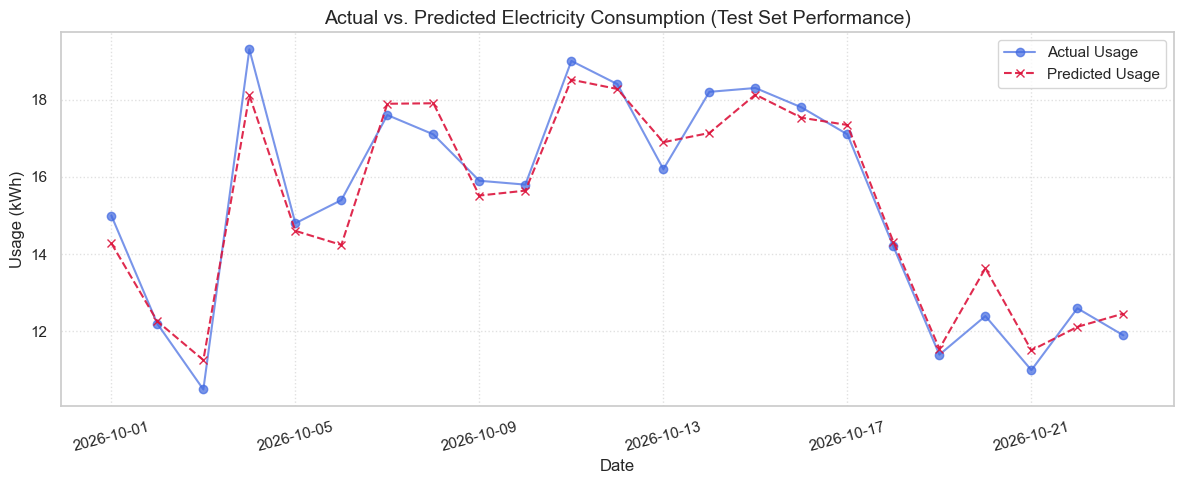

In [7]:
# Generate predictions directly in this cell to ensure y_pred is defined
y_pred = model.predict(X_test)

# Plotting Actual vs Predicted Values over Time
plt.figure(figsize=(12, 5))

# Use the corresponding dates from the test set split
test_dates = df.iloc[split_idx:]['Date']

plt.plot(test_dates, y_test.values, label='Actual Usage', color='royalblue', marker='o', alpha=0.7)
plt.plot(test_dates, y_pred, label='Predicted Usage', color='crimson', linestyle='--', marker='x', alpha=0.9)

plt.title('Actual vs. Predicted Electricity Consumption (Test Set Performance)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Usage (kWh)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

---
### Save the model to a .pkl file for future use

In [8]:
joblib.dump(model, 'model.pkl')
print("Model saved as 'model.pkl'. Ready for deployment!")

Model saved as 'model.pkl'. Ready for deployment!


---
### Next Steps

1. Ensure prerequisites: Make sure you have the required libraries installed in your environment:
```Bash
pip install pandas scikit-learn joblib
```
2. Execution: Run the cells sequentially.

3. Verification: Check your folder. You should now see a newly generated model.pkl file.